# Customer Segmentation Starter Notebook

Dataset expected at `../data/raw/online_retail_II.xlsx`.

This notebook builds a baseline RFM clustering pipeline.

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

In [12]:
# Load Online Retail dataset from common locations/formats
from pathlib import Path

candidate_paths = [
    Path("../data/raw/online_retail_II.xlsx"),
    Path("../data/raw/Online Retail II.xlsx"),
    Path("../data/raw/online_retail.xlsx"),
    Path("../data/raw/Online Retail.xlsx"),
    Path("../data/raw/online_retail.csv"),
    Path("../data/raw/Online Retail.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Put the file in ../data/raw/ and name it one of: "
        "online_retail_II.xlsx, Online Retail II.xlsx, online_retail.xlsx, "
        "Online Retail.xlsx, online_retail.csv, Online Retail.csv"
    )

if data_path.suffix.lower() == ".csv":
    df = pd.read_csv(data_path)
else:
    df = pd.read_excel(data_path, sheet_name=0)

print(f"Loaded: {data_path}")
print(df.shape)
df.head()

Loaded: ../data/raw/online_retail_II.xlsx
(525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
# Basic cleaning
df = df.dropna(subset=["Customer ID"]).copy()
df["Invoice"] = df["Invoice"].astype(str)
df = df[~df["Invoice"].str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalAmount"] = df["Quantity"] * df["Price"]

print(df.shape)
df.head()

(407664, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [14]:
# Build RFM features
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("TotalAmount", "sum"),
    )
    .reset_index()
)

# Handle skew
rfm[["Frequency", "Monetary"]] = np.log1p(rfm[["Frequency", "Monetary"]])
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,2.484907,5.923881
1,12347.0,3,1.098612,7.188654
2,12348.0,74,0.693147,5.407889
3,12349.0,43,1.386294,7.890635
4,12351.0,11,0.693147,5.710195


In [15]:
# Scale features and test k values
features = ["Recency", "Frequency", "Monetary"]
X = StandardScaler().fit_transform(rfm[features])

scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    scores[k] = silhouette_score(X, labels)

scores

{2: 0.40022557908043827,
 3: 0.41170795546118977,
 4: 0.37208426826947033,
 5: 0.3428457488448743,
 6: 0.3428514978601892,
 7: 0.3336464302514039,
 8: 0.3107494003356111}

In [16]:
# Train final baseline model (adjust n_clusters using score + interpretability)
best_k = max(scores, key=scores.get)
model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
rfm["Cluster"] = model.fit_predict(X)

cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_size = rfm["Cluster"].value_counts().sort_index().rename("Size")

# Business-friendly segment names based on relative RFM pattern
cluster_name_map = {
    0: "Champions",
    1: "At-Risk",
    2: "Potential Loyalists",
}
rfm["SegmentName"] = rfm["Cluster"].map(cluster_name_map)

display(cluster_profile)
display(cluster_size)
rfm.head()

,Recency,Frequency,Monetary
Cluster,,,
0,34.06,2.18,8.00
1,249.76,0.85,5.59
2,54.24,1.07,6.16


Cluster
0    1361
1     955
2    1996
Name: Size, dtype: int64

,Customer ID,Recency,Frequency,Monetary,Cluster,SegmentName
0,12346.0,165,2.484907,5.923881,0,Champions
1,12347.0,3,1.098612,7.188654,2,Potential Loyalists
2,12348.0,74,0.693147,5.407889,2,Potential Loyalists
3,12349.0,43,1.386294,7.890635,0,Champions
4,12351.0,11,0.693147,5.710195,2,Potential Loyalists


## Model Comparison, Visualization, and Export

Run the next cells to:
- compare KMeans with GMM,
- visualize segments in PCA space,
- generate business summaries,
- and export customer-level segments to `../data/processed/customer_segments.csv`.

In [17]:
# Compare KMeans vs Gaussian Mixture Model (same number of clusters)
gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X)

gmm_silhouette = silhouette_score(X, gmm_labels)
kmeans_silhouette = scores[best_k]

comparison = pd.DataFrame(
    {
        "Model": ["KMeans", "GMM"],
        "Silhouette": [kmeans_silhouette, gmm_silhouette],
    }
).sort_values("Silhouette", ascending=False)

comparison

,Model,Silhouette
0,KMeans,0.411708
1,GMM,0.172944


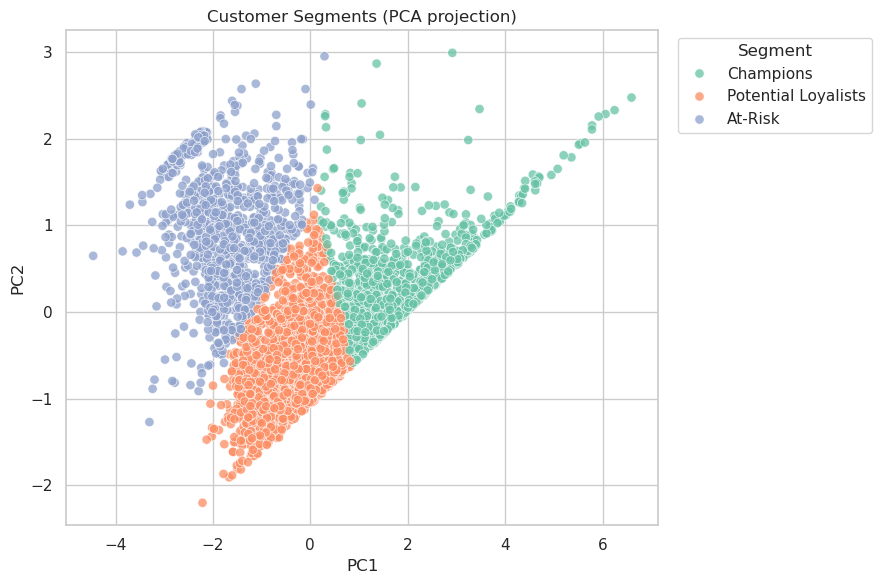

In [18]:
# PCA visualization of KMeans segments
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plot_df = rfm.copy()
plot_df["PC1"] = X_pca[:, 0]
plot_df["PC2"] = X_pca[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="SegmentName",
    palette="Set2",
    alpha=0.75,
    s=45,
)
plt.title("Customer Segments (PCA projection)")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
# Segment summary table (include non-log monetary for business readability)
customer_value = (
    df.groupby("Customer ID")
    .agg(
        Orders=("Invoice", "nunique"),
        Revenue=("TotalAmount", "sum"),
    )
    .reset_index()
)

rfm_business = rfm.merge(customer_value, on="Customer ID", how="left")

segment_summary = (
    rfm_business.groupby("SegmentName")
    .agg(
        Customers=("Customer ID", "count"),
        AvgRecencyDays=("Recency", "mean"),
        AvgOrders=("Orders", "mean"),
        AvgRevenue=("Revenue", "mean"),
    )
    .round(2)
    .sort_values("AvgRevenue", ascending=False)
)

display(segment_summary)

# Export final customer segments
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "customer_segments.csv"

rfm_business[[
    "Customer ID",
    "Cluster",
    "SegmentName",
    "Recency",
    "Orders",
    "Revenue",
    "Frequency",
    "Monetary",
]].to_csv(output_path, index=False)

print(f"Saved: {output_path.resolve()}")

,Customers,AvgRecencyDays,AvgOrders,AvgRevenue
SegmentName,,,,
Champions,1361,34.06,10.06,5267.64
Potential Loyalists,1996,54.24,2.08,630.81
At-Risk,955,249.76,1.43,422.66


Saved: /home/teoyongsong/unsupervised-clustering-online-retail/data/processed/customer_segments.csv


## Recommended Actions by Segment

- **Champions**: early access launches, loyalty rewards, and referral incentives.
- **Potential Loyalists**: nudges for second/third purchase, product bundles, personalized cross-sell.
- **At-Risk**: win-back campaigns, stronger discounts, and reactivation email journeys.

If needed, tune `cluster_name_map` after reviewing the latest `segment_summary` values.